In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
df = pd.read_csv("/content/india_job_market_2024_2026.csv")
print("Shape:", df.shape)
display(df.head())
display(df.info())


Shape: (5000, 17)


,Job_ID,Job_Title,Company,Company_Type,Industry,City,Location_Tier,Experience_Level,Job_Type,Work_Mode,Salary_LPA,Skills_Required,Education_Required,Openings,Applicants,Company_Rating,Date_Posted
0,IND2025000,Android Developer,Tech Mahindra,MNC,Information Technology,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,30.9,"Kotlin, Java, REST APIs",M.Tech/M.E.,3,276,4.0,2025-10-31
1,IND2025001,QA Engineer,Dream11,Indian Unicorn,Information Technology,Lucknow,Tier 2,Senior (6-10 yrs),Full-Time,Hybrid,58.6,"Selenium, Manual Testing, Postman, API Testing...",B.Tech/B.E.,3,325,4.0,2025-05-19
2,IND2025002,Business Analyst,HAL,PSU/Govt,EdTech,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,18.4,"JIRA, Excel, Power BI",MCA,5,559,3.6,2024-08-21
3,IND2025003,Cybersecurity Analyst,Groww,Startup,Information Technology,Mumbai,Tier 1,Mid (3-6 yrs),Full-Time,Hybrid,21.7,"Penetration Testing, Python, Ethical Hacking, ...",BCA,3,184,3.5,2026-03-18
4,IND2025004,Python Developer,Oracle,MNC,EdTech,Remote,Remote,Junior (1-3 yrs),Full-Time,Remote,8.0,"Docker, REST APIs, AWS, PostgreSQL",MCA,1,64,3.9,2024-10-25


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Job_ID              5000 non-null   object 
 1   Job_Title           5000 non-null   object 
 2   Company             5000 non-null   object 
 3   Company_Type        5000 non-null   object 
 4   Industry            5000 non-null   object 
 5   City                5000 non-null   object 
 6   Location_Tier       5000 non-null   object 
 7   Experience_Level    5000 non-null   object 
 8   Job_Type            5000 non-null   object 
 9   Work_Mode           5000 non-null   object 
 10  Salary_LPA          5000 non-null   float64
 11  Skills_Required     5000 non-null   object 
 12  Education_Required  5000 non-null   object 
 13  Openings            5000 non-null   int64  
 14  Applicants          5000 non-null   int64  
 15  Company_Rating      5000 non-null   float64
 16  Date_P

None

# Basic data-quality checks

In [4]:
display(df.describe(include="all").T)
print("Duplicate rows:", df.duplicated().sum())
display(df.isna().sum().sort_values(ascending=False).to_frame("Missing Values"))


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Job_ID,5000,5000,IND2029999,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job_Title,5000,30,Software Engineer,336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Company,5000,53,Wipro,134,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Company_Type,5000,4,MNC,1717,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Industry,5000,15,Information Technology,1545,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,5000,17,Remote,1992,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location_Tier,5000,3,Tier 1,2086,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience_Level,5000,5,Mid (3-6 yrs),1378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job_Type,5000,4,Full-Time,3648,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Work_Mode,5000,3,On-Site,2005,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Duplicate rows: 0


,Missing Values
Job_ID,0
Job_Title,0
Company,0
Company_Type,0
Industry,0
City,0
Location_Tier,0
Experience_Level,0
Job_Type,0
Work_Mode,0


In [5]:
d = df.copy()
d["Date_Posted"] = pd.to_datetime(d["Date_Posted"], errors="coerce")

d["posted_year"] = d["Date_Posted"].dt.year
d["posted_month"] = d["Date_Posted"].dt.month
d["posted_quarter"] = d["Date_Posted"].dt.quarter
d["posted_dayofweek"] = d["Date_Posted"].dt.dayofweek
d["posted_dayofmonth"] = d["Date_Posted"].dt.day

d["applicants_per_opening"] = (
    d["Applicants"] / d["Openings"].replace(0, np.nan)
).replace([np.inf, -np.inf], np.nan)

display(d.head())


,Job_ID,Job_Title,Company,Company_Type,Industry,City,Location_Tier,Experience_Level,Job_Type,Work_Mode,...,Openings,Applicants,Company_Rating,Date_Posted,posted_year,posted_month,posted_quarter,posted_dayofweek,posted_dayofmonth,applicants_per_opening
0,IND2025000,Android Developer,Tech Mahindra,MNC,Information Technology,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,...,3,276,4.0,2025-10-31,2025,10,4,4,31,92.000000
1,IND2025001,QA Engineer,Dream11,Indian Unicorn,Information Technology,Lucknow,Tier 2,Senior (6-10 yrs),Full-Time,Hybrid,...,3,325,4.0,2025-05-19,2025,5,2,0,19,108.333333
2,IND2025002,Business Analyst,HAL,PSU/Govt,EdTech,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,...,5,559,3.6,2024-08-21,2024,8,3,2,21,111.800000
3,IND2025003,Cybersecurity Analyst,Groww,Startup,Information Technology,Mumbai,Tier 1,Mid (3-6 yrs),Full-Time,Hybrid,...,3,184,3.5,2026-03-18,2026,3,1,2,18,61.333333
4,IND2025004,Python Developer,Oracle,MNC,EdTech,Remote,Remote,Junior (1-3 yrs),Full-Time,Remote,...,1,64,3.9,2024-10-25,2024,10,4,4,25,64.000000


# Target and Feature Selection

In [6]:
target = "Salary_LPA"
features = [c for c in d.columns if c not in [target, "Job_ID", "Date_Posted", "Skills_Required"]]

X = d[features]
y = d[target]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)


Categorical: ['Job_Title', 'Company', 'Company_Type', 'Industry', 'City', 'Location_Tier', 'Experience_Level', 'Job_Type', 'Work_Mode', 'Education_Required']
Numeric: ['Openings', 'Applicants', 'Company_Rating', 'posted_year', 'posted_month', 'posted_quarter', 'posted_dayofweek', 'posted_dayofmonth', 'applicants_per_opening']


# Preprocessing and 80/20 Train-Test Split

In [7]:
preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=2))
    ]), categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 4000
Testing rows: 1000


# Linear Regression Baseline

In [8]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_r2 = r2_score(y_test, linear_pred)

print(f"RMSE: {linear_rmse:.4f}")
print(f"MAE : {linear_mae:.4f}")
print(f"R²  : {linear_r2:.4f}")


RMSE: 8.0694
MAE : 5.3306
R²  : 0.7964


# Random Forest Regression

In [9]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print(f"RMSE: {rf_rmse:.4f}")
print(f"MAE : {rf_mae:.4f}")
print(f"R²  : {rf_r2:.4f}")


RMSE: 4.3523
MAE : 2.7090
R²  : 0.9408


# Model Comparison

In [10]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "RMSE": [linear_rmse, rf_rmse],
    "MAE": [linear_mae, rf_mae],
    "R2": [linear_r2, rf_r2]
})
display(results)


,Model,RMSE,MAE,R2
0,Linear Regression,8.069434,5.330575,0.796394
1,Random Forest,4.352332,2.708959,0.940769


# Feature Importance

,Feature,Importance
133,cat__Experience_Level_Lead (10+ yrs),0.389204
135,cat__Experience_Level_Senior (6-10 yrs),0.207897
138,cat__Job_Type_Internship,0.149186
94,cat__Company_Type_PSU/Govt,0.096200
134,cat__Experience_Level_Mid (3-6 yrs),0.058391
92,cat__Company_Type_Indian Unicorn,0.014081
93,cat__Company_Type_MNC,0.012513
1,num__Applicants,0.005881
7,num__posted_dayofmonth,0.005703
8,num__applicants_per_opening,0.005593


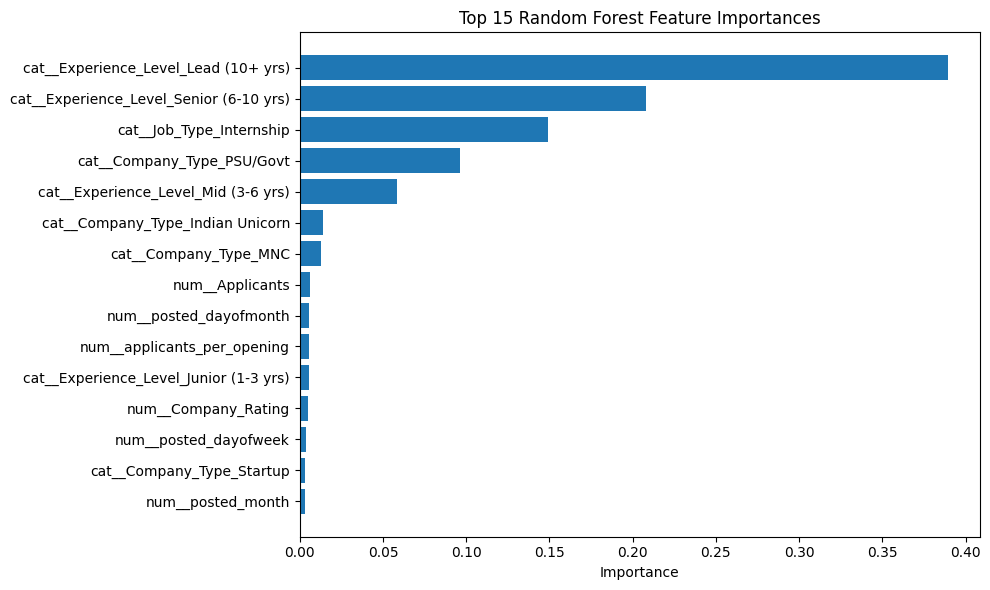

In [11]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
importance = rf_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=False)

display(feature_importance.head(15))

plt.figure(figsize=(10, 6))
top = feature_importance.head(15).sort_values("Importance")
plt.barh(top["Feature"], top["Importance"])
plt.xlabel("Importance")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()


# Actual vs Predicted Values

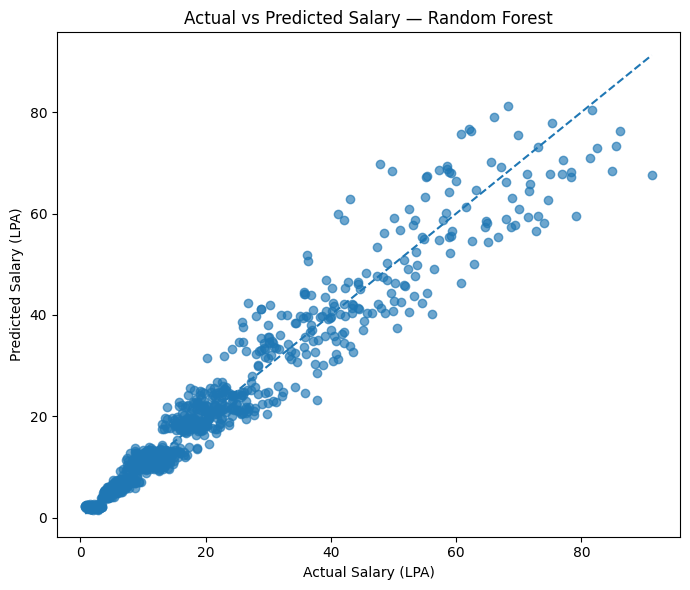

In [12]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, rf_pred, alpha=0.65)
mn = min(y_test.min(), rf_pred.min())
mx = max(y_test.max(), rf_pred.max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("Actual Salary (LPA)")
plt.ylabel("Predicted Salary (LPA)")
plt.title("Actual vs Predicted Salary — Random Forest")
plt.tight_layout()
plt.show()


# Hyperparameter Tuning

In [13]:
search = RandomizedSearchCV(
    Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
    ]),
    {
        "model__n_estimators": [100, 150, 200],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", 0.7]
    },
    n_iter=6,
    cv=2,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Best parameters:")
print(search.best_params_)


Best parameters:
{'model__n_estimators': 150, 'model__min_samples_leaf': 2, 'model__max_features': 0.7, 'model__max_depth': 20}


In [14]:
tuned_pred = search.predict(X_test)

tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))
tuned_mae = mean_absolute_error(y_test, tuned_pred)
tuned_r2 = r2_score(y_test, tuned_pred)

final_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Tuned Random Forest"],
    "RMSE": [linear_rmse, rf_rmse, tuned_rmse],
    "MAE": [linear_mae, rf_mae, tuned_mae],
    "R2": [linear_r2, rf_r2, tuned_r2]
})
display(final_results)


,Model,RMSE,MAE,R2
0,Linear Regression,8.069434,5.330575,0.796394
1,Random Forest,4.352332,2.708959,0.940769
2,Tuned Random Forest,4.342470,2.713677,0.941037


In [15]:
final_results.to_csv("model_comparison_final.csv", index=False)
feature_importance.head(15).to_csv("top_feature_importance.csv", index=False)